In [4]:
from ultralytics import YOLO

SOURCE = "/Users/artemsaltanovskyi/Documents/2025-2026-2/2MCTE2-Advancded_AI/exam/AIProject2026/Data/Dataset/images/test"
RESULTS_DIR = "/Users/artemsaltanovskyi/Documents/2025-2026-2/2MCTE2-Advancded_AI/exam/AIProject2026/Models/Results"

model = YOLO("yolo11n.pt")

count = 0
for r in model.predict(
    source=SOURCE,
    imgsz=640,
    conf=0.25,
    save=True,
    project=RESULTS_DIR,
    name="predict",
    exist_ok=True,
    stream=True,
    verbose=False,
):
    count += 1

print("Done")
print("Images processed:", count)

Results saved to /Users/artemsaltanovskyi/Documents/2025-2026-2/2MCTE2-Advancded_AI/exam/AIProject2026/Models/Results/predict
Done
Images processed: 2584


Images found: 2584

Processing: frame_010338.jpg
Detections: 1


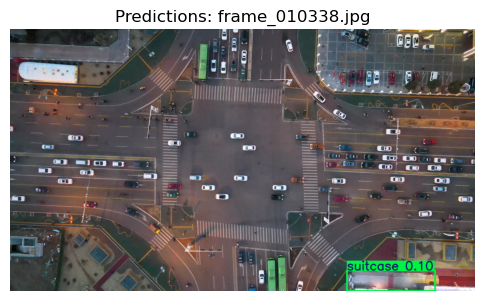


Processing: frame_010339.jpg
Detections: 1


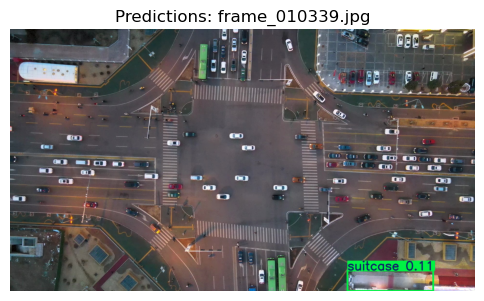


Processing: frame_010340.jpg
Detections: 1


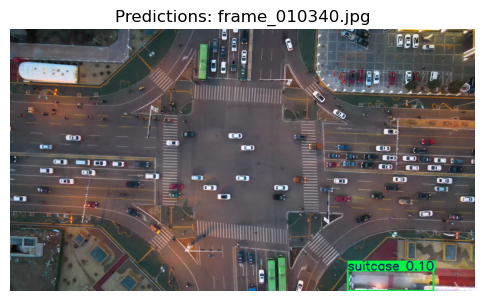


Processing: frame_010341.jpg
Detections: 1


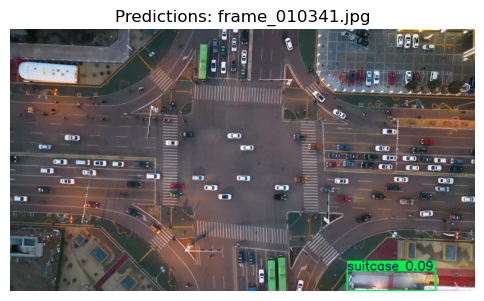


Processing: frame_010342.jpg
Detections: 4


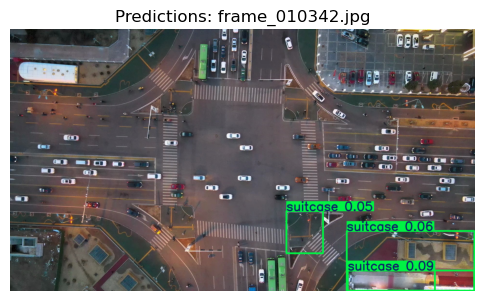


Processing: frame_010343.jpg
Detections: 2


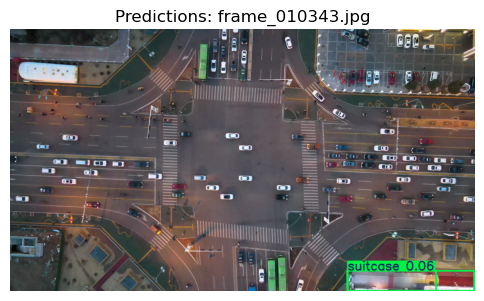


Processing: frame_010344.jpg
Detections: 1


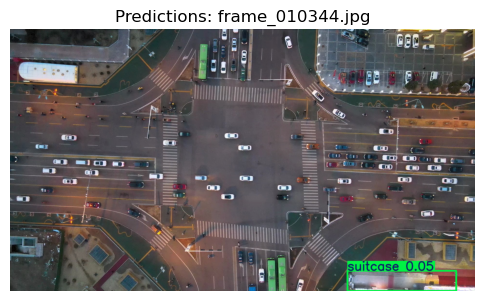


Processing: frame_010345.jpg
Detections: 1


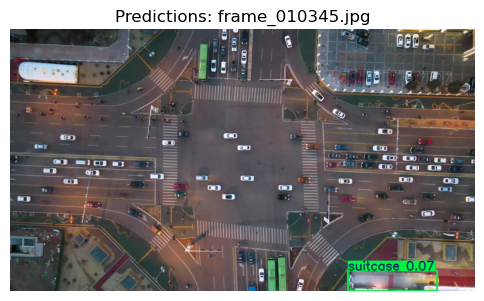


Processing: frame_010346.jpg
Detections: 1


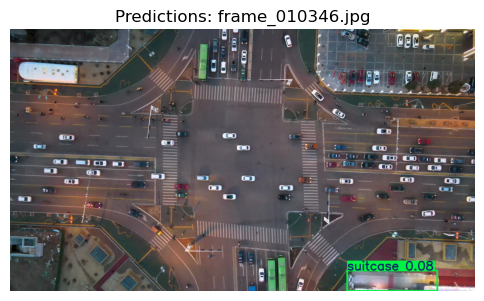


Processing: frame_010347.jpg
Detections: 1


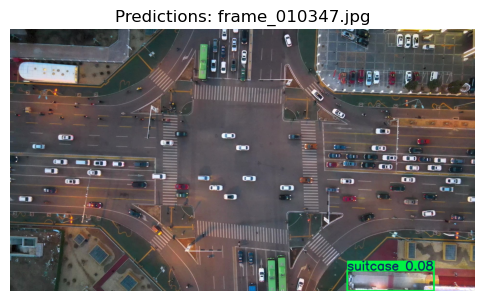


Processing: frame_010348.jpg
Detections: 1


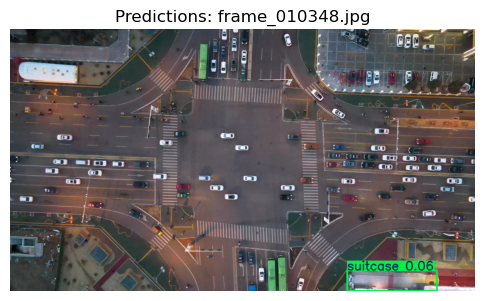


Processing: frame_010349.jpg
Detections: 0


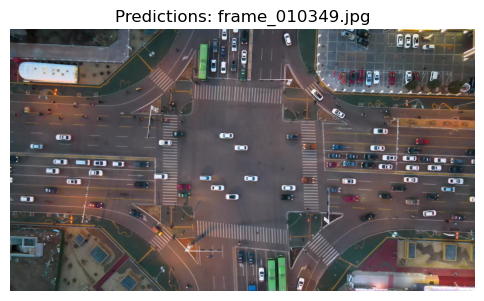


Processing: frame_010350.jpg
Detections: 5


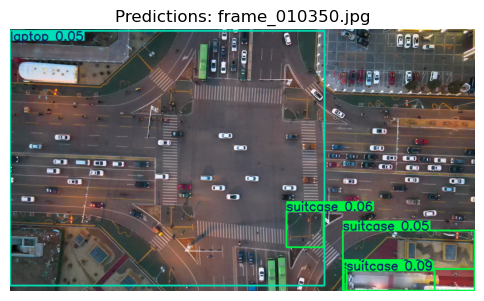


Processing: frame_010351.jpg
Detections: 2


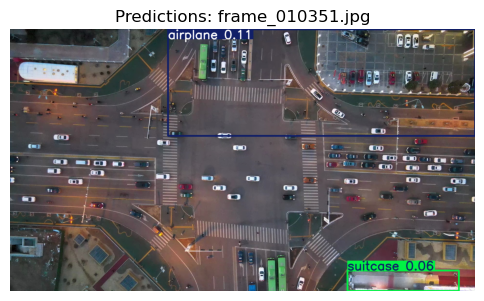


Processing: frame_010352.jpg
Detections: 1


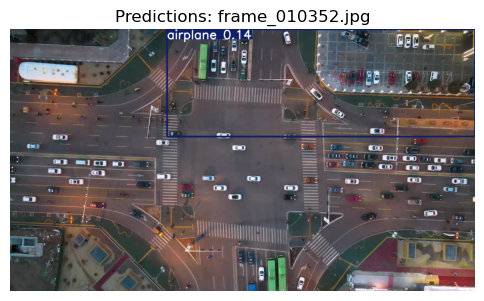


Processing: frame_010353.jpg
Detections: 1


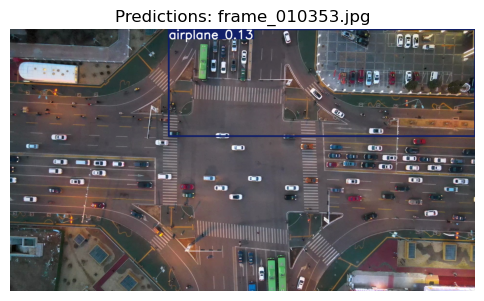


Processing: frame_010354.jpg
Detections: 2


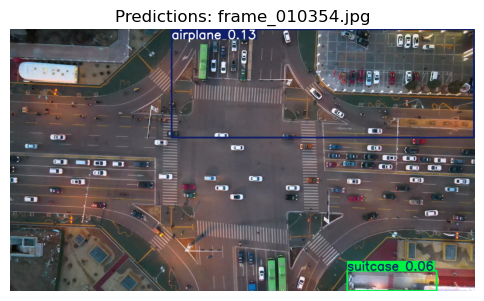


Processing: frame_010355.jpg
Detections: 1


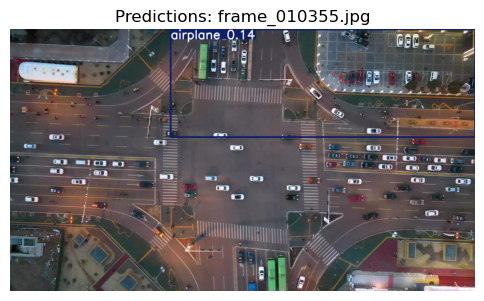


Processing: frame_010356.jpg
Detections: 1


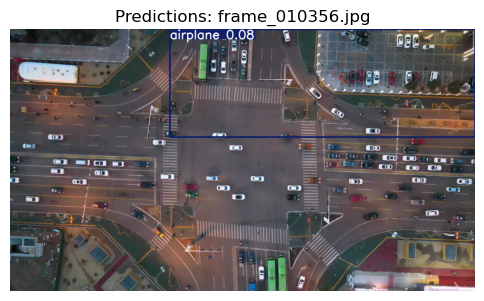


Processing: frame_010357.jpg
Detections: 1


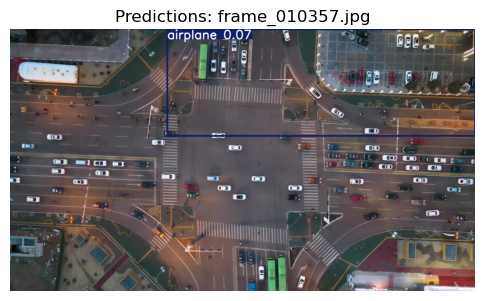

In [18]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt

IMAGES_DIR = Path("/Users/artemsaltanovskyi/Documents/2025-2026-2/2MCTE2-Advancded_AI/exam/AIProject2026/Models/Results/predict")

model = YOLO("yolo11n.pt")

image_files = sorted(list(IMAGES_DIR.glob("*.jpg")) + list(IMAGES_DIR.glob("*.jpeg")) + list(IMAGES_DIR.glob("*.png")))

print("Images found:", len(image_files))

num_to_show = min(20, len(image_files))

for image_path in image_files[:num_to_show]:
    print(f"\nProcessing: {image_path.name}")

    results = model.predict(
        source=str(image_path),
        imgsz=1024,      
        conf=0.05,     
        verbose=False
    )

    r = results[0]

    annotated = r.plot()

    annotated_rgb = annotated[:, :, ::-1]

    print("Detections:", len(r.boxes))

    plt.figure(figsize=(6, 4))
    plt.imshow(annotated_rgb)
    plt.title(f"Predictions: {image_path.name}")
    plt.axis("off")
    plt.show()